# Exercise 02: Bar

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/checking-logs.sqlite')

## Analyzing only the users

In [2]:
df = pd.read_sql("""
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%'
""", conn, parse_dates=['timestamp'])


## Creating time intervals

In [3]:
def get_period(hour):
    if 0 <= hour <= 3:
        return 'night'
    elif 4 <= hour <= 9:
        return 'morning'
    elif 10 <= hour <= 16:
        return 'afternoon'
    else:
        return 'evening'

df['hour'] = df['timestamp'].dt.hour
df['period'] = df['hour'].apply(get_period)
df['date'] = df['timestamp'].dt.date

## Pivot table (reorganizing data)

In [4]:
pivot = df.pivot_table(
    index='date',
    columns='period',
    aggfunc='size',
    fill_value=0
)

pivot = pivot[['night', 'morning', 'afternoon', 'evening']]
pivot = pivot.sort_index()

## Plotting bar chart

Text(0.5, 0, '')

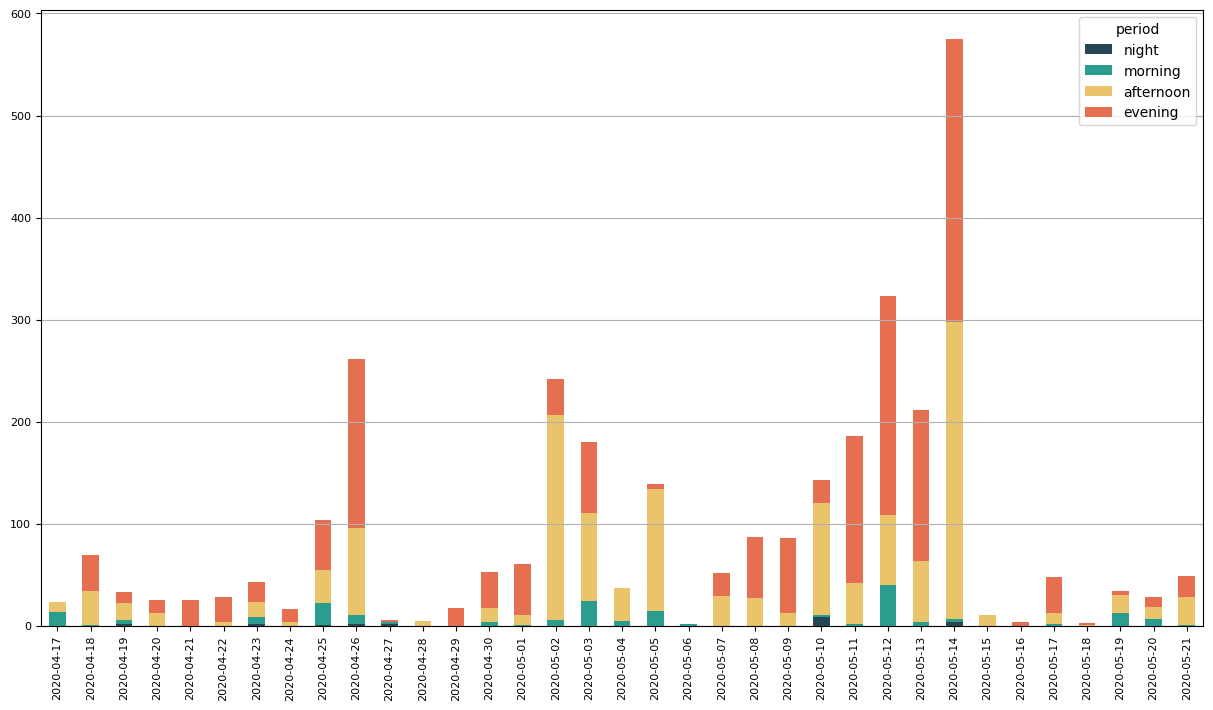

In [5]:
pivot = pivot.sort_index()

df = pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(15,8),
    fontsize=8,
    color=['#264653', '#2A9D8F', '#E9C46A', '#E76F51']
)

df.yaxis.grid(True)
df.set_xlabel('')

In [6]:
conn.close()

##### When do our users usually commit to the labs: in the night, morning, afternoon, or evening? Clearly, evening and afternoon 

##### Which day has:
    - the most number of commits? 2020-05-14 (close to 600)

    - and at the same time, is the number of commits higher in the evening than in the afternoon? Arguably, in 2020-05-14 afternoon has more commits than evening, so answer could be 2020-05-12